In [15]:
threads = 16
import os
os.environ["MKL_NUM_THREADS"] = str(threads)
os.environ["NUMEXPR_NUM_THREADS"] = str(threads)
os.environ["OMP_NUM_THREADS"] = str(threads)

import Functions as fn
import numpy as np
import CRUMPET
import matplotlib.pyplot as plt
import fc_mapping as fc
import scipy.interpolate as interpolate
import scipy.integrate as integrate

In [16]:
#default Eirene setup with Eirene rates
fn.gen_input('input_Eirene.dat', vibr_hyd=True, incl_ground=False, diss_hyd=True,diss_ion=False,mol_cx_hyd=True,ion_hyd=True,MA=False,MolIonR=True)
crm_Eirene = CRUMPET.Crumpet('input_Eirene.dat')

['H2VIBR_OR', 'H.2', '2.0v1']
['H2VIBR_OR', 'H.2', '2.1v0']
['H2VIBR_OR', 'H.2', '2.1v2']
['H2VIBR_OR', 'H.2', '2.2v1']
['H2VIBR_OR', 'H.2', '2.2v3']
['H2VIBR_OR', 'H.2', '2.3v2']
['H2VIBR_OR', 'H.2', '2.3v4']
['H2VIBR_OR', 'H.2', '2.4v3']
['H2VIBR_OR', 'H.2', '2.4v5']
['H2VIBR_OR', 'H.2', '2.5v4']
['H2VIBR_OR', 'H.2', '2.5v6']
['H2VIBR_OR', 'H.2', '2.6v5']
['H2VIBR_OR', 'H.2', '2.6v7']
['H2VIBR_OR', 'H.2', '2.7v6']
['H2VIBR_OR', 'H.2', '2.7v8']
['H2VIBR_OR', 'H.2', '2.8v7']
['H2VIBR_OR', 'H.2', '2.8v9']
['H2VIBR_OR', 'H.2', '2.9v8']
['H2VIBR_OR', 'H.2', '2.9v10']
['H2VIBR_OR', 'H.2', '2.10v9']
['H2VIBR_OR', 'H.2', '2.10v11']
['H2VIBR_OR', 'H.2', '2.11v10']
['H2VIBR_OR', 'H.2', '2.11v12']
['H2VIBR_OR', 'H.2', '2.12v11']
['H2VIBR_OR', 'H.2', '2.12v13']
['H2VIBR_OR', 'H.2', '2.13v12']
['H2VIBR_OR', 'H.2', '2.13v14']
['H2VIBR_OR', 'H.2', '2.14v13']
['H2VIBR_OR', 'H.2', '2.0l2']
['H2VIBR_OR', 'H.2', '2.1l2']
['H2VIBR_OR', 'H.2', '2.2l2']
['H2VIBR_OR', 'H.2', '2.3l2']
['H2VIBR_OR', 'H.2', '

100%|██████████| 14/14 [00:00<00:00, 14129.03it/s]


Constructing functional emissivity matrix


100%|██████████| 14/14 [00:00<00:00, 14445.33it/s]


Constructing functional energy transfer matrix


100%|██████████| 14/14 [00:00<00:00, 10510.16it/s]


In [17]:
#setup with Eirene rates and Ichihara molecular CX as well as H- (Laporta) HYDROGEN
fn.gen_input('input_Eirene_MolCXIchi_HminLaporta_H.dat', vibr_hyd=True, incl_ground=False, diss_hyd=True,diss_ion=False,mol_cx=True,ion_hyd=True,diss_att_X1=True,MA=False,MA_min=False,MolIonR=True,molcxindx='q5')
crm_Eirene_MolCXIchi_HminLaporta_H = CRUMPET.Crumpet('input_Eirene_MolCXIchi_HminLaporta_H.dat')

['H2VIBR_OR', 'H.2', '2.0v1']
['H2VIBR_OR', 'H.2', '2.1v0']
['H2VIBR_OR', 'H.2', '2.1v2']
['H2VIBR_OR', 'H.2', '2.2v1']
['H2VIBR_OR', 'H.2', '2.2v3']
['H2VIBR_OR', 'H.2', '2.3v2']
['H2VIBR_OR', 'H.2', '2.3v4']
['H2VIBR_OR', 'H.2', '2.4v3']
['H2VIBR_OR', 'H.2', '2.4v5']
['H2VIBR_OR', 'H.2', '2.5v4']
['H2VIBR_OR', 'H.2', '2.5v6']
['H2VIBR_OR', 'H.2', '2.6v5']
['H2VIBR_OR', 'H.2', '2.6v7']
['H2VIBR_OR', 'H.2', '2.7v6']
['H2VIBR_OR', 'H.2', '2.7v8']
['H2VIBR_OR', 'H.2', '2.8v7']
['H2VIBR_OR', 'H.2', '2.8v9']
['H2VIBR_OR', 'H.2', '2.9v8']
['H2VIBR_OR', 'H.2', '2.9v10']
['H2VIBR_OR', 'H.2', '2.10v9']
['H2VIBR_OR', 'H.2', '2.10v11']
['H2VIBR_OR', 'H.2', '2.11v10']
['H2VIBR_OR', 'H.2', '2.11v12']
['H2VIBR_OR', 'H.2', '2.12v11']
['H2VIBR_OR', 'H.2', '2.12v13']
['H2VIBR_OR', 'H.2', '2.13v12']
['H2VIBR_OR', 'H.2', '2.13v14']
['H2VIBR_OR', 'H.2', '2.14v13']
['H2VIBR', 'H.2', '2.0q5']
['H2VIBR', 'H.2', '2.1q5']
['H2VIBR', 'H.2', '2.2q5']
['H2VIBR', 'H.2', '2.3q5']
['H2VIBR', 'H.2', '2.4q5']
['H2VIB

100%|██████████| 14/14 [00:00<00:00, 12047.65it/s]


Constructing functional emissivity matrix


100%|██████████| 14/14 [00:00<00:00, 13957.75it/s]


Constructing functional energy transfer matrix


100%|██████████| 14/14 [00:00<00:00, 11559.11it/s]


In [18]:
#setup with Eirene rates and Ichihara molecular CX as well as H- (Laporta) DEUTERIUM
fn.gen_input('input_Eirene_MolCXIchi_HminLaporta_D.dat', vibr_hyd=True, incl_ground=False, diss_hyd=True,
             diss_ion=False, mol_cx=True, ion_hyd=True, diss_att_X1=True, MA=False, MA_min=False, MolIonR=True)
crm_Eirene_MolCXIchi_HminLaporta_D = CRUMPET.Crumpet('input_Eirene_MolCXIchi_HminLaporta_D.dat')

['H2VIBR_OR', 'H.2', '2.0v1']
['H2VIBR_OR', 'H.2', '2.1v0']
['H2VIBR_OR', 'H.2', '2.1v2']
['H2VIBR_OR', 'H.2', '2.2v1']
['H2VIBR_OR', 'H.2', '2.2v3']
['H2VIBR_OR', 'H.2', '2.3v2']
['H2VIBR_OR', 'H.2', '2.3v4']
['H2VIBR_OR', 'H.2', '2.4v3']
['H2VIBR_OR', 'H.2', '2.4v5']
['H2VIBR_OR', 'H.2', '2.5v4']
['H2VIBR_OR', 'H.2', '2.5v6']
['H2VIBR_OR', 'H.2', '2.6v5']
['H2VIBR_OR', 'H.2', '2.6v7']
['H2VIBR_OR', 'H.2', '2.7v6']
['H2VIBR_OR', 'H.2', '2.7v8']
['H2VIBR_OR', 'H.2', '2.8v7']
['H2VIBR_OR', 'H.2', '2.8v9']
['H2VIBR_OR', 'H.2', '2.9v8']
['H2VIBR_OR', 'H.2', '2.9v10']
['H2VIBR_OR', 'H.2', '2.10v9']
['H2VIBR_OR', 'H.2', '2.10v11']
['H2VIBR_OR', 'H.2', '2.11v10']
['H2VIBR_OR', 'H.2', '2.11v12']
['H2VIBR_OR', 'H.2', '2.12v11']
['H2VIBR_OR', 'H.2', '2.12v13']
['H2VIBR_OR', 'H.2', '2.13v12']
['H2VIBR_OR', 'H.2', '2.13v14']
['H2VIBR_OR', 'H.2', '2.14v13']
['H2VIBR', 'H.2', '2.0q6']
['H2VIBR', 'H.2', '2.1q6']
['H2VIBR', 'H.2', '2.2q6']
['H2VIBR', 'H.2', '2.3q6']
['H2VIBR', 'H.2', '2.4q6']
['H2VIB

100%|██████████| 14/14 [00:00<00:00, 12225.75it/s]


Constructing functional emissivity matrix


100%|██████████| 14/14 [00:00<00:00, 14197.35it/s]


Constructing functional energy transfer matrix


100%|██████████| 14/14 [00:00<00:00, 12592.81it/s]


In [19]:
#Compute vibrational distribution as function of T (assumes Ti=Te, accounts for deuterium ion mass)
import numpy as np
Te_reso = 100
Tev = 10**np.linspace(np.log10(0.1), np.log10(100), Te_reso)
iso_mass=2
Tiv = Tev/iso_mass
ne = 1e19

fv_D2_MolCXIchi_HminLaporta = np.ones([15,len(Tev)])
fv_D2 = np.ones([15,len(Tev)])
for i in range(0,len(Tev)):
    fv_D2_MolCXIchi_HminLaporta[1:,i]=crm_Eirene_MolCXIchi_HminLaporta_D.steady_state(Tev[i],ne*1e-6,Ti=Tev[i], plot=False,dt=True)[0:14]
    fv_D2[1:,i]=crm_Eirene.steady_state(Tev[i],ne*1e-6,Ti=Tiv[i], plot=False,dt=True)[0:14]

iso_mass=1

fv_H2_MolCXIchi_HminLaporta = np.ones([15,len(Tev)])
fv_H2 = np.ones([15,len(Tev)])
for i in range(0,len(Tev)):
    fv_H2_MolCXIchi_HminLaporta[1:,i]=crm_Eirene_MolCXIchi_HminLaporta_H.steady_state(Tev[i],ne*1e-6,Ti=Tev[i], plot=False,dt=True)[0:14]
    fv_H2[1:,i]=crm_Eirene.steady_state(Tev[i],ne*1e-6,Ti=Tiv[i], plot=False,dt=True)[0:14]


Text(0.5, 1.0, 'Deuterium vibrational distribution - Eirene - MolCX Ichihara; DA Laporta')

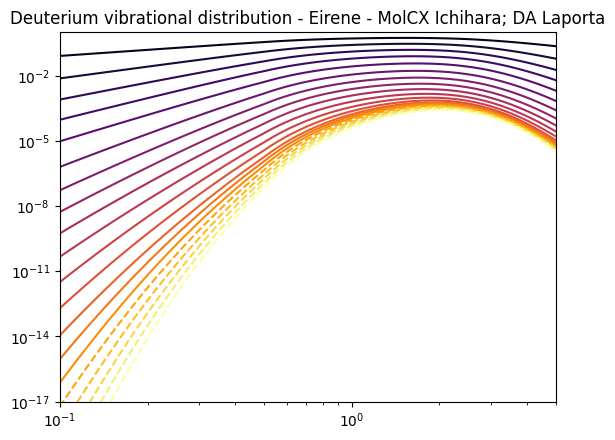

In [20]:
#Extrapolate vibrational distribution - required for Hmin calculation
from scipy.interpolate import interp1d
import numpy as np
lvl = np.linspace(0,14,15)
fv_H2_extrap_MolCXIchi_HminLaporta = np.zeros([21,len(Tev)])
fv_H2_extrap = np.zeros([21,len(Tev)])
fv_D2_extrap_MolCXIchi_HminLaporta = np.zeros([21,len(Tev)])
fv_D2_extrap = np.zeros([21,len(Tev)])
for i in range(0,len(Tev)):
    f = interp1d(lvl,np.log(fv_D2_MolCXIchi_HminLaporta[:,i]),bounds_error=False,fill_value='extrapolate')
    fv_D2_extrap_MolCXIchi_HminLaporta[:,i] = np.exp(f(np.linspace(0,20,21)))
    #fv_H2_extrap_MolCXIchi_HminLaporta[:,i] = fv_H2_extrap_MolCXIchi_HminLaporta[:,i] / sum(fv_H2_extrap_MolCXIchi_HminLaporta[:,i])
    f = interp1d(lvl,np.log(fv_D2[:,i]),bounds_error=False,fill_value='extrapolate')
    fv_D2_extrap[:,i] = np.exp(f(np.linspace(0,20,21)))
    f = interp1d(lvl,np.log(fv_H2_MolCXIchi_HminLaporta[:,i]),bounds_error=False,fill_value='extrapolate')
    fv_H2_extrap_MolCXIchi_HminLaporta[:,i] = np.exp(f(np.linspace(0,20,21)))
    #fv_H2_extrap_MolCXIchi_HminLaporta[:,i] = fv_H2_extrap_MolCXIchi_HminLaporta[:,i] / sum(fv_H2_extrap_MolCXIchi_HminLaporta[:,i])
    f = interp1d(lvl,np.log(fv_H2[:,i]),bounds_error=False,fill_value='extrapolate')
    fv_H2_extrap[:,i] = np.exp(f(np.linspace(0,20,21)))
    #fv_H2_extrap[:,i] = fv_H2_extrap[:,i] / sum(fv_H2_extrap[:,i])


#visualise vibrational distribution - extrapolated
import matplotlib.pyplot as plt
plt.figure()
colors = plt.cm.inferno(np.linspace(0,1,np.shape(fv_D2_extrap_MolCXIchi_HminLaporta)[0]))
for i in range(1,np.shape(fv_D2_extrap_MolCXIchi_HminLaporta)[0]):
    if i<16:
        plt.loglog(Tev,np.transpose(fv_D2_extrap_MolCXIchi_HminLaporta[i,:]),'-',color=colors[i,:])
    if i>=16:
        plt.loglog(Tev,np.transpose(fv_D2_extrap_MolCXIchi_HminLaporta[i,:]),'--',color=colors[i,:])
plt.axis([0.1,5,1e-17,1])
plt.title('Deuterium vibrational distribution - Eirene - MolCX Ichihara; DA Laporta')


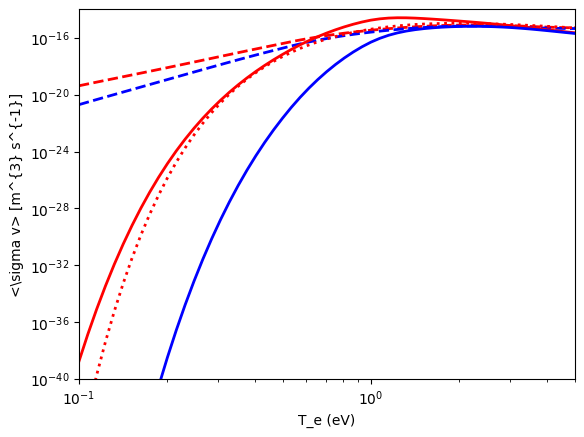

In [34]:
#Compute effective rates - MAR & MAD

#codes for evaluating Eirene-like fits
def eval_2D(coeff, T, n):
    '''
    Function to evaluate 2D polynomial logarithmic fits of reaction rate coefficients of the type in Eirene data files (e.g. AMJUEL).
    In this case, the rate coefficients have both a temperature and density dependence.

        Parameters
        ----------
        coeff: numpy array
            Fit constants of the rate coefficients. (For Eirene data, this is an 8x8 array)
        T: float
            Evaluation temperature in eV (may also be an array of temperatures).
        n: float
            Evaluation density in m^-3 (may also be an array of densities).

        Output
        ------
        Reaction rate coefficient(s) in m^3s^-1.
    '''

    o = np.zeros(np.shape(T))
    for i in range(0, np.shape(coeff)[0]):
        for j in range(0, np.shape(coeff)[1]):
            o = o + coeff[i, j] * (np.log(T) ** i) * (np.log(n * 1e-14) ** j)
    return 1e-6 * np.exp(o)

def eval_1D(coeff, T):
    o = np.zeros(np.shape(T))
    for i in range(0, len(coeff)):
        o = o + coeff[i] * (np.log(T) ** i)
    return 1e-6 * np.exp(o)

#Load in reaction sets
H2VIBR_custom = CRUMPET.ratedata.RateData(rates={'H2VIBR' : '/rates/h2vibr_custom.tex'})
H2VIBR_original = CRUMPET.ratedata.RateData(rates={'H2VIBR_OR' : '/rates/h2vibr.tex'})
AMJUEL = CRUMPET.ratedata.RateData(rates={'AMJUEL' : '/rates/amjuel.tex'})

nev = ne*np.ones(np.shape(Tev))

#Compute effective dissociative attachment and molecular CX rates
da_rate = np.zeros(np.shape(Tev))

for i in range(0,len(Tev)):
    for j in range(0,21):
        da_rate[i] = da_rate[i] + eval_1D(H2VIBR_custom.reactions['H2VIBR']['H.2']['2.'+str(j)+'L4'], Tev[i])*fv_D2_extrap_MolCXIchi_HminLaporta[j,i]

cx_rate_Ichi_H = np.zeros(np.shape(Tev))

for i in range(0,len(Tev)):
    for j in range(0,15):
        cx_rate_Ichi_H[i] = cx_rate_Ichi_H[i] + eval_1D(H2VIBR_custom.reactions['H2VIBR']['H.2']['2.'+str(j)+'Q5'], Tev[i])*fv_H2_MolCXIchi_HminLaporta[j,i]

cx_rate_Ichi_D = np.zeros(np.shape(Tev))

for i in range(0,len(Tev)):
    for j in range(0,15):
        cx_rate_Ichi_D[i] = cx_rate_Ichi_D[i] + eval_1D(H2VIBR_custom.reactions['H2VIBR']['H.2']['2.'+str(j)+'Q6'], Tev[i])*fv_D2_MolCXIchi_HminLaporta[j,i]

cx_rate_Eirene_D = np.zeros(np.shape(Tev))

for i in range(0,len(Tev)):
    for j in range(0,15):
        cx_rate_Eirene_D[i] = cx_rate_Eirene_D[i] + eval_1D(H2VIBR_original.reactions['H2VIBR_OR']['H.2']['2.'+str(j)+'L2'], Tev[i]/2)*fv_H2[j,i]

cx_rate_Eirene_H = np.zeros(np.shape(Tev))

for i in range(0,len(Tev)):
    for j in range(0,15):
        cx_rate_Eirene_H[i] = cx_rate_Eirene_H[i] + eval_1D(H2VIBR_original.reactions['H2VIBR_OR']['H.2']['2.'+str(j)+'L2'], Tev[i])*fv_D2[j,i]

cx_rate_Eirene = eval_1D(AMJUEL.reactions['AMJUEL']['H.2']['3.2.3'],Tev)

Te_Reiter = np.array([1,2,3])
MolCX_Reiter = np.array([10.48, 27.12, 38.08])*1e-10*1e-6

plt.figure()
#plt.loglog(Te_Reiter,MolCX_Reiter,'md',markersize=15)
plt.loglog(Tev, cx_rate_Ichi_H,'r--',linewidth=2)
plt.loglog(Tev, cx_rate_Ichi_D,'b--',linewidth=2)
plt.loglog(Tev, cx_rate_Eirene_H,'r',linewidth=2)
plt.loglog(Tev, cx_rate_Eirene_D,'b',linewidth=2)
plt.loglog(Tev, cx_rate_Eirene,'r:',linewidth=2)
#plt.loglog(Tev, eval_1D(AMJUEL.reactions['AMJUEL']['H.2']['3.2.3'],Tev),'g',linewidth=2)
#plt.loglog(Tev, da_rate, 'c--',linewidth=2)
plt.axis([0.1, 5, 1e-40, 1e-14])
plt.xlabel('T_e (eV)')
plt.ylabel('<\sigma v> [m^{3} s^{-1}]')
plt.savefig('MolCX_calculations.eps')